In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import scipy as sp


In [3]:
math_marks=pd.read_csv('math_marks.csv')
print(math_marks)

    student_id  mechanics  vectors  algebra  analysis  statistics
0            1         77       82       67        67          81
1            2         63       78       80        70          81
2            3         75       73       71        66          81
3            4         55       72       63        70          68
4            5         63       63       65        70          63
..         ...        ...      ...      ...       ...         ...
83          84         15       38       39        28          17
84          85          5       30       44        36          18
85          86         12       30       32        35          21
86          87          5       26       15        20          20
87          88          0       40       21         9          14

[88 rows x 6 columns]


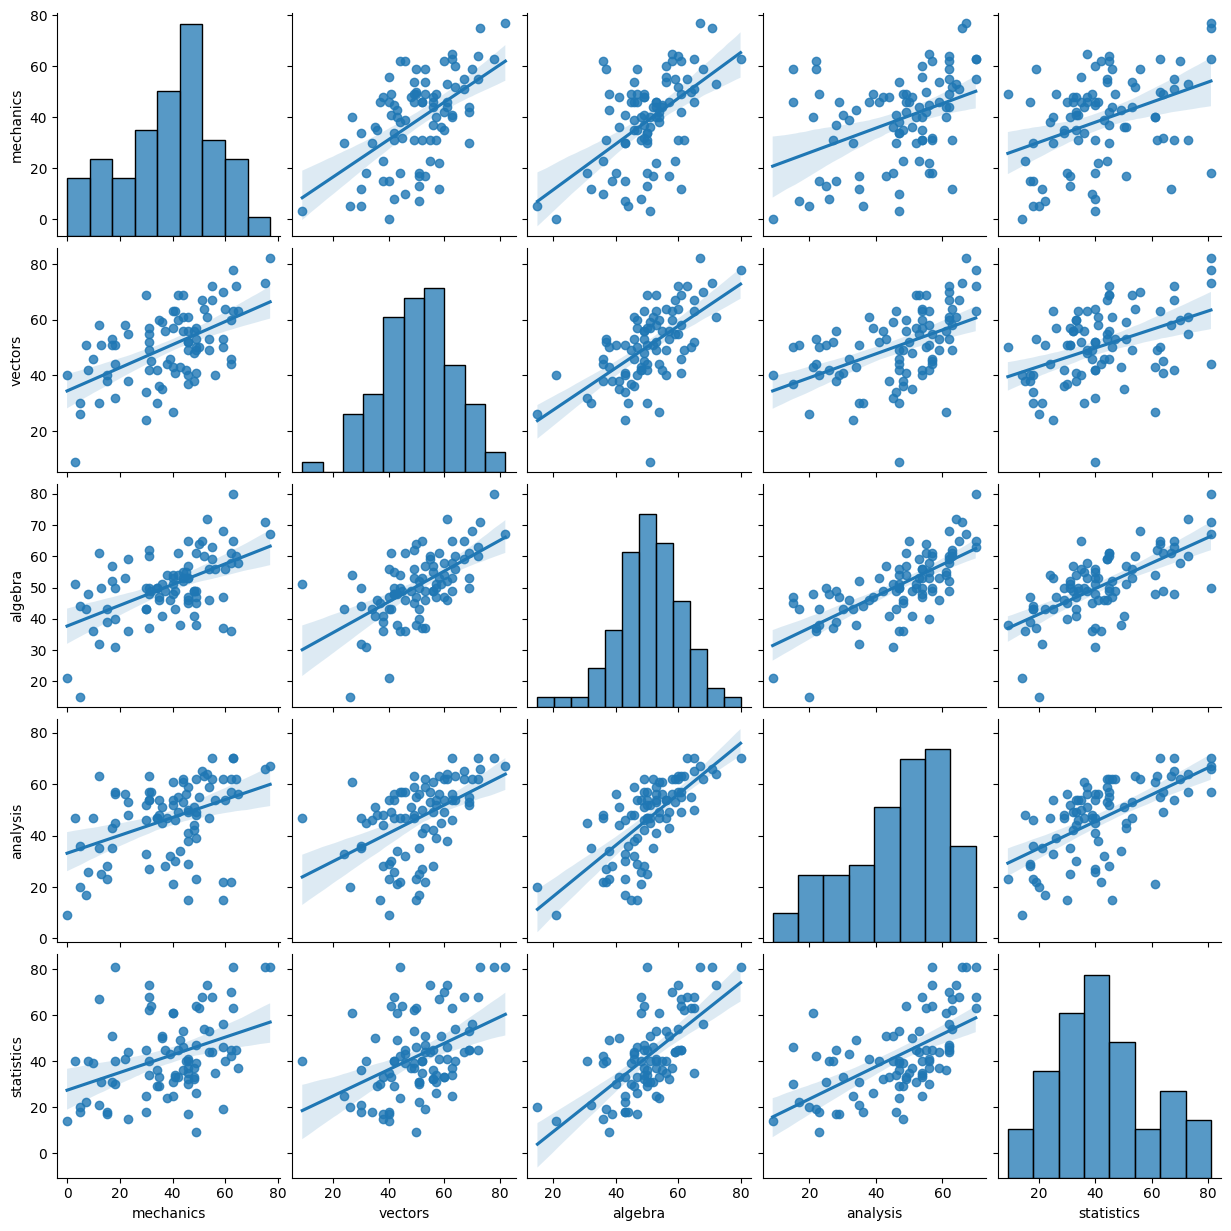

In [4]:
sns.pairplot(math_marks[['mechanics', 'vectors', 'algebra', 'analysis', 'statistics']], kind='reg')
plt.savefig('pairwise_scatter.png')
plt.show()

From the plot, we can see that there seems to be positive corelation between:
- mechanics and vectors, mechanics and algebra
- vectors and algebra, vectors and analysis
- algebra and analysis, algebra and statistics
- analysis and statistics

There is no negative correlation among any of the features



In [5]:
corr_math=math_marks[['mechanics', 'vectors', 'algebra', 'analysis', 'statistics']].corr()

In [6]:
print(corr_math)

            mechanics   vectors   algebra  analysis  statistics
mechanics    1.000000  0.552698  0.546228  0.409636    0.389443
vectors      0.552698  1.000000  0.609645  0.485081    0.436449
algebra      0.546228  0.609645  1.000000  0.710806    0.664736
analysis     0.409636  0.485081  0.710806  1.000000    0.607174
statistics   0.389443  0.436449  0.664736  0.607174    1.000000


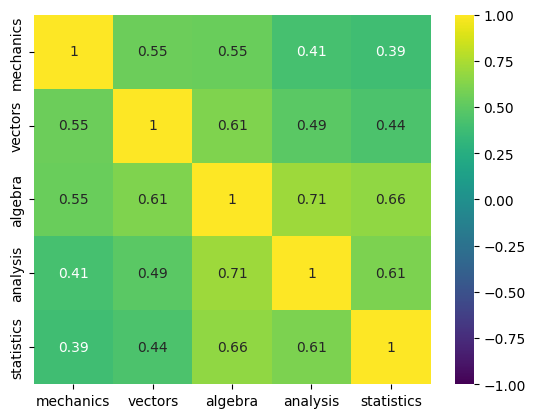

In [7]:
sns.heatmap(corr_math, cmap='viridis', annot=True, vmin=-1, vmax=+1) 

#vmin, vmax needed to ensure the colors are according to the full range possible, not just the range observed
plt.savefig('heatmap_corr.png')
plt.show()

The variables which are highly correlated are:
- algebra and analysis(0.71)
- algebra and statistics(0.66)
- algebra and vectors(0.61)
- statistics and analysis(0.61)


In [8]:
print(type(corr_math))

<class 'pandas.core.frame.DataFrame'>


In [9]:
inv_corr_math=np.linalg.inv(corr_math) 


In [10]:
print(inv_corr_math) #labels lost

[[ 1.60155714e+00 -5.57861846e-01 -5.05923734e-01  1.33011981e-03
  -4.47391933e-02]
 [-5.57861846e-01  1.80110261e+00 -6.59051987e-01 -1.54151212e-01
  -3.71414349e-02]
 [-5.05923734e-01 -6.59051987e-01  3.04110209e+00 -1.11121485e+00
  -8.62157281e-01]
 [ 1.33011981e-03 -1.54151212e-01 -1.11121485e+00  2.17799734e+00
  -5.16998691e-01]
 [-4.47391933e-02 -3.71414349e-02 -8.62157281e-01 -5.16998691e-01
   1.92064876e+00]]


In [11]:
inv_corr_math_df= pd.DataFrame(inv_corr_math, index=corr_math.index, columns=corr_math.columns) #convert to dataframe

In [12]:
print(inv_corr_math_df)

            mechanics   vectors   algebra  analysis  statistics
mechanics    1.601557 -0.557862 -0.505924  0.001330   -0.044739
vectors     -0.557862  1.801103 -0.659052 -0.154151   -0.037141
algebra     -0.505924 -0.659052  3.041102 -1.111215   -0.862157
analysis     0.001330 -0.154151 -1.111215  2.177997   -0.516999
statistics  -0.044739 -0.037141 -0.862157 -0.516999    1.920649


In [13]:
D=np.diag(inv_corr_math)


In [15]:
S=1-1/D
print(S)

[0.37560767 0.44478455 0.67117184 0.54086262 0.4793426 ]


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [18]:
feature_list= list(math_marks.columns[1:]) #getting a list of all 5 features
print(feature_list)

['mechanics', 'vectors', 'algebra', 'analysis', 'statistics']


In [19]:
r_squared_dict={}
for f in feature_list:
    X = math_marks.iloc[:, 1:].drop(columns=f)
    y = math_marks.loc[:, f]
    model=LinearRegression()
    model.fit(X, y)
    y_predicted=model.predict(X)
    r_squared=r2_score(y, y_predicted) # R^2 depends only on the true and predicted values
    r_squared_dict[f]= r_squared


    
    


In [20]:
print(r_squared_dict)

{'mechanics': 0.3756076664277902, 'vectors': 0.44478454798463385, 'algebra': 0.6711718410270189, 'analysis': 0.5408626171831168, 'statistics': 0.4793425958671891}


From the R squared values, we notice that for certain features, most of the variance is not explained by the linear model

for mechanics, only 38% of the variance is explained by the linear model

for algebra, 67% of the variance is explained by the linear model which is best among all the features

In [23]:
cov_math=math_marks[['mechanics', 'vectors', 'algebra', 'analysis', 'statistics']].cov()
print(cov_math)

             mechanics     vectors     algebra    analysis  statistics
mechanics   305.688480  127.043365  101.469044  106.322362  117.493339
vectors     127.043365  172.842215   85.157262   94.672936   99.012017
algebra     101.469044   85.157262  112.885972  112.113375  121.870559
analysis    106.322362   94.672936  112.113375  220.380355  155.535528
statistics  117.493339   99.012017  121.870559  155.535528  297.755355


In [24]:
P=np.linalg.inv(cov_math)
print(P)

[[ 5.23918056e-03 -2.42695773e-03 -2.72348840e-03  5.12465682e-06
  -1.48292376e-04]
 [-2.42695773e-03  1.04205018e-02 -4.71818292e-03 -7.89833576e-04
  -1.63720844e-04]
 [-2.72348840e-03 -4.71818292e-03  2.69395926e-02 -7.04517217e-03
  -4.70258573e-03]
 [ 5.12465682e-06 -7.89833576e-04 -7.04517217e-03  9.88290150e-03
  -2.01824188e-03]
 [-1.48292376e-04 -1.63720844e-04 -4.70258573e-03 -2.01824188e-03
   6.45042559e-03]]


In [25]:
P_df= pd.DataFrame(P, index=cov_math.index, columns=cov_math.columns) #convert to dataframe
print(P_df)

            mechanics   vectors   algebra  analysis  statistics
mechanics    0.005239 -0.002427 -0.002723  0.000005   -0.000148
vectors     -0.002427  0.010421 -0.004718 -0.000790   -0.000164
algebra     -0.002723 -0.004718  0.026940 -0.007045   -0.004703
analysis     0.000005 -0.000790 -0.007045  0.009883   -0.002018
statistics  -0.000148 -0.000164 -0.004703 -0.002018    0.006450


In [26]:
K = np.zeros_like(P) #initialize as empty
for i in range(len(feature_list)):
    K[i, i]=1
    for j in range(i+1, len(feature_list)):
        K[i, j]= -(P[i, j])/np.sqrt(P[i, i]*P[j, j])
        K[j, i]=K[i, j] #using the symmteric nature of K

In [27]:
print(K)

[[ 1.00000000e+00  3.28462817e-01  2.29244188e-01 -7.12181801e-04
   2.55089719e-02]
 [ 3.28462817e-01  1.00000000e+00  2.81601489e-01  7.78303605e-02
   1.99694211e-02]
 [ 2.29244188e-01  2.81601489e-01  1.00000000e+00  4.31771394e-01
   3.56736071e-01]
 [-7.12181801e-04  7.78303605e-02  4.31771394e-01  1.00000000e+00
   2.52776557e-01]
 [ 2.55089719e-02  1.99694211e-02  3.56736071e-01  2.52776557e-01
   1.00000000e+00]]


In [28]:
K_df=pd.DataFrame(K, index=cov_math.index, columns=cov_math.columns)
print(K_df)

            mechanics   vectors   algebra  analysis  statistics
mechanics    1.000000  0.328463  0.229244 -0.000712    0.025509
vectors      0.328463  1.000000  0.281601  0.077830    0.019969
algebra      0.229244  0.281601  1.000000  0.431771    0.356736
analysis    -0.000712  0.077830  0.431771  1.000000    0.252777
statistics   0.025509  0.019969  0.356736  0.252777    1.000000


This K is a measure of the conditional dependence/independence between the features

In [35]:
#partial correlation function:

def part_corr(str1, str2):
    y1=math_marks[str1]
    y2=math_marks[str2]
    X = math_marks[feature_list].drop(columns=[str1, str2]) #keep other 3
    model1=LinearRegression()
    model2=LinearRegression()
    model1.fit(X, y1)
    model2.fit(X, y2)
    y1_pred=model1.predict(X)
    y2_pred=model2.predict(X)
    r1=y1_pred-y1
    r2=y2_pred-y2
    corr_residuals=np.corrcoef(r1, r2)[0,1]#correlation of residuals and getting the correlation value
    return corr_residuals
   
    
    
    

In [45]:
mech_mech=part_corr('mechanics', 'mechanics')
mech_vector=part_corr('mechanics', 'vectors')
mech_alg=part_corr('mechanics', 'algebra')
mech_anal=part_corr('mechanics', 'analysis')
mech_stat=part_corr('mechanics', 'statistics')

In [46]:
print(mech_mech, mech_vector, mech_alg, mech_anal, mech_stat)

0.9999999999999999 0.32846281686695894 0.22924418849138337 -0.0007121818006189239 0.025508971860107692


We can see that these values are precisely the 1st row of the K matrix(which is the scaled precision matrix)

They are equal because both are computing the same thing (the partial correlation through 2 different means). The 2 means are equal by a theorem covered in class

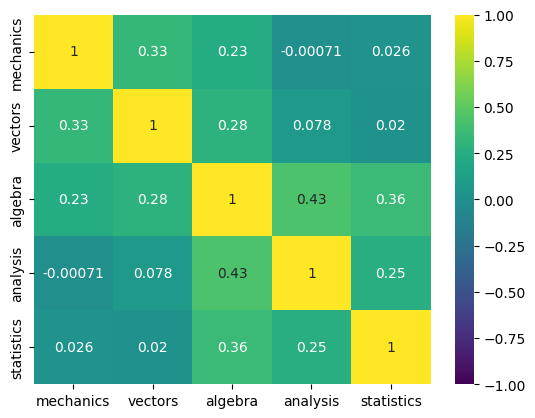

In [48]:
sns.heatmap(K_df, cmap='viridis', annot=True, vmin=-1, vmax=+1)
plt.savefig('heatmap_part_corr.png')
plt.show()

We can see that the values in this heatmap are smaller than the values in the correlation heatmap, this is to be expected since this particular heatmap is only looking at only the direct correlation between 2 features; after adjusting for the indirect correlation due to other 3 features

In [49]:
import networkx as nx

In [51]:
G=nx.Graph()
G.add_nodes_from(feature_list)

In [63]:
for i in range(len(feature_list)):
    for j in range(i+1, len(feature_list)):
        
        G.add_edge(K_df.index[i], K_df.columns[j], weight=np.round(K_df.iloc[i, j], 2))


In [64]:
print(G)

Graph with 5 nodes and 10 edges


In [75]:
pos = nx.circular_layout(G) #circular working better than spring for less number of points


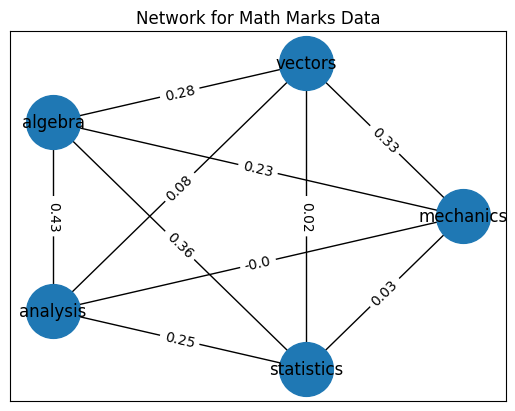

In [77]:
nx.draw_networkx_nodes(G, pos, node_size=1500)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos) #for node names

edge_labels = nx.get_edge_attributes(G, "weight") #to get edge labels, in this case weight
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title('Network for Math Marks Data')
plt.savefig('network_part_corr.png')
plt.show()

#this is very simple, of course it is possible to make the edge thickness proportional to the magnitude of the edge weight